# 02 — Minimum Free-Energy Folding: Decomposing and Interpreting $\Delta G$

## Learning objectives

By the end of this notebook you will be able to:

- Explain the nearest-neighbor free-energy model as a **sum of independent loop
  contributions**, and map each term to a piece of secondary structure.
- Use `fold_compound.eval_structure_verbose` to **decompose a folded structure's
  MFE into per-loop free energies**, and visualize that decomposition.
- Explain why the MFE depends on **model details** (temperature, dangle
  treatment, lonely-pair handling) and quantify those effects.
- Use `eval_structure` to evaluate the free energy of *any* structure for a
  given sequence — not just the MFE — enabling "what if" comparisons.
- Reproduce and interpret a GC-content vs. free-energy relationship across many
  random sequences.

**Prerequisites**: [01_introduction.ipynb](01_introduction.ipynb) — dot-bracket
notation, `RNA.fold`, fold compounds, basic `forgi` diagrams.


## 1. Introduction & motivation

Notebook 1 introduced the minimum free-energy (MFE) structure as "the structure
with the lowest $\Delta G$", computed it with `RNA.fold` and `fold_compound.mfe()`,
and drew it. That treated $\Delta G$ as a single opaque number.

In practice, $\Delta G$ is never one number drawn from a black box — it is a
**sum of many small, physically interpretable terms**, one per structural
element (helix stack, hairpin loop, bulge, multiloop junction, ...). Two
consequences follow directly from this, and both are the subject of this
notebook:

1. **You can decompose** a structure's total free energy back into those terms,
   which tells you *which parts of the molecule* are thermodynamically
   stabilizing vs. destabilizing — useful for explaining *why* a particular
   fold wins.
2. **The terms depend on conditions** — temperature above all, but also on
   modeling choices such as how dangling ends and lonely base pairs are
   treated. Changing these conditions changes $\Delta G$ for *every* candidate
   structure, which is why folding predictions are only meaningful alongside
   the model details used to make them.

**Roadmap**: theory first (the loop-decomposition sum and its temperature
dependence), then three worked examples — decomposing a single structure,
sweeping model details, and a GC-content vs. energy study across many random
sequences — followed by a combined case study, best practices, and exercises.


## 2. Theoretical background: the nearest-neighbor free-energy model

### 2.1 Free energy as a sum over loops

A secondary structure $s$ for sequence $x$ partitions $x$ into a set of
**loops** — independent structural elements whose boundaries are base pairs
(or the sequence ends). The nearest-neighbor model assigns each loop $\ell$ an
empirically measured free-energy contribution $\Delta G_\ell$, and the total
free energy of the structure is simply their sum:

$$
\Delta G(s \mid x) \;=\; \sum_{\ell \,\in\, \text{loops}(s)} \Delta G_\ell .
$$

The loop types you will see in this notebook's decompositions are:

| Loop type | What it is | Typical sign |
| :--- | :--- | :--- |
| **Stack / interior loop (0 unpaired)** | Two consecutive base pairs stacked on top of each other | Negative (stabilizing) |
| **Interior loop (≥1 unpaired)** | A bulge or internal loop between two helices | Positive (destabilizing), with a small bonus for favorable mismatches |
| **Hairpin loop** | The unpaired loop closing a helix at its tip | Positive (entropic cost of closing a loop) |
| **Multi loop** | The junction where ≥3 helices meet | Positive, roughly linear in the number of helices/unpaired bases |
| **External loop** | Unpaired bases and helices exposed to the exterior | 0 with no dangling-end bonus, or negative if dangling ends stack favorably against the outermost helices |

Each term comes from an experimentally calibrated table (the "Turner
parameters"), indexed by the identity of the closing base pair(s) and, for
loops, the sequence of unpaired bases inside them.

### 2.2 Temperature dependence

The tabulated parameters are free energies at a reference temperature
$T_0 = 37\,^{\circ}\mathrm{C}$. Each parameter is actually stored as an
enthalpy/entropy pair $(\Delta H, \Delta S)$ and extrapolated via the
Gibbs–Helmholtz relation

$$
\Delta G(T) \;=\; \Delta H \;-\; T\,\Delta S ,
$$

with $T$ in Kelvin. ViennaRNA performs this rescaling automatically whenever
you change `RNA.md().temperature` (in $^{\circ}\mathrm{C}$) and build a new
fold compound — every $\Delta G_\ell$ in the sum above shifts, so the MFE
*and* which structure attains it can both change with temperature.

### 2.3 Connecting theory to the API

| Theory concept | ViennaRNA API |
| :--- | :--- |
| $\Delta G(s \mid x)$ for the MFE structure | `fold_compound.mfe()` → `(structure, mfe)` |
| $\Delta G(s \mid x)$ for an **arbitrary** structure $s$ | `fold_compound.eval_structure(s)` |
| The per-loop terms $\Delta G_\ell$ in the sum | `fold_compound.eval_structure_verbose(s)` (prints one line per loop) |
| Model details $(T, \text{dangles}, \text{noLP}, \dots)$ | `RNA.md()` passed to `RNA.fold_compound(seq, md)` |


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io
import os
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

LOOP_COLORS = {
    "External loop": PALETTE[7],
    "Interior loop": PALETTE[0],
    "Hairpin  loop": PALETTE[3],
    "Multi loop": PALETTE[2],
}


## 3. Worked example 1 — decomposing a structure's free energy by loop

`fold_compound.eval_structure_verbose` prints (to the C-level standard output,
bypassing Python's `print`) one line per loop, giving its location, closing
base pair(s), and free-energy contribution in units of $10\,\text{cal/mol}$.
The helper below captures that stream at the file-descriptor level and parses
it into a tidy `pandas.DataFrame` with energies converted to kcal/mol — turning
a diagnostic printout into reusable data.


In [2]:
def eval_structure_verbose_df(fc, structure):
    '''Run eval_structure_verbose and return (total_energy, DataFrame of per-loop terms).'''
    read_fd, write_fd = os.pipe()
    saved_stdout = os.dup(1)
    os.dup2(write_fd, 1)
    os.close(write_fd)
    try:
        total = fc.eval_structure_verbose(structure)
    finally:
        os.dup2(saved_stdout, 1)
        os.close(saved_stdout)

    raw = b""
    while True:
        chunk = os.read(read_fd, 4096)
        if not chunk:
            break
        raw += chunk
    os.close(read_fd)

    rows = []
    pattern = re.compile(r"^(.*loop)\s*(.*?):\s*(-?\d+)\s*$")
    for line in raw.decode().strip().splitlines():
        m = pattern.match(line)
        if m:
            rows.append({
                "loop_type": m.group(1).strip(),
                "detail": m.group(2).strip(),
                "energy_kcal": int(m.group(3)) / 100.0,
            })
    return total, pd.DataFrame(rows)


# A small hairpin-within-hairpin sequence, same family as notebook 1's example.
seq_1 = "GGGAAACCCAAAGGGAAACCC"
fc_1 = RNA.fold_compound(seq_1)
structure_1, mfe_1 = fc_1.mfe()
total_1, decomp_1 = eval_structure_verbose_df(fc_1, structure_1)

print(f"Sequence:  {seq_1}")
print(f"Structure: {structure_1}")
print(f"MFE:       {mfe_1:.2f} kcal/mol  (sum of the table below: {decomp_1['energy_kcal'].sum():.2f})")
decomp_1


Sequence:  GGGAAACCCAAAGGGAAACCC
Structure: (((...(((...)))...)))
MFE:       -5.80 kcal/mol  (sum of the table below: -5.80)


,loop_type,detail,energy_kcal
0,External loop,,0.0
1,Interior loop,"( 1, 21) GC; ( 2, 20) GC",-3.3
2,Interior loop,"( 2, 20) GC; ( 3, 19) GC",-3.3
3,Interior loop,"( 3, 19) GC; ( 7, 15) CG",2.0
4,Interior loop,"( 7, 15) CG; ( 8, 14) CG",-3.3
5,Interior loop,"( 8, 14) CG; ( 9, 13) CG",-3.3
6,Hairpin loop,"( 9, 13) CG",5.4


Each row above is one term in $\Delta G(s\mid x) = \sum_\ell \Delta G_\ell$.
The figure below shows this decomposition two ways side by side: a **grouped
bar chart** of every individual loop term (left), and the matching **forgi
structure diagram** (right) so you can see *where* each contribution sits in
the molecule.


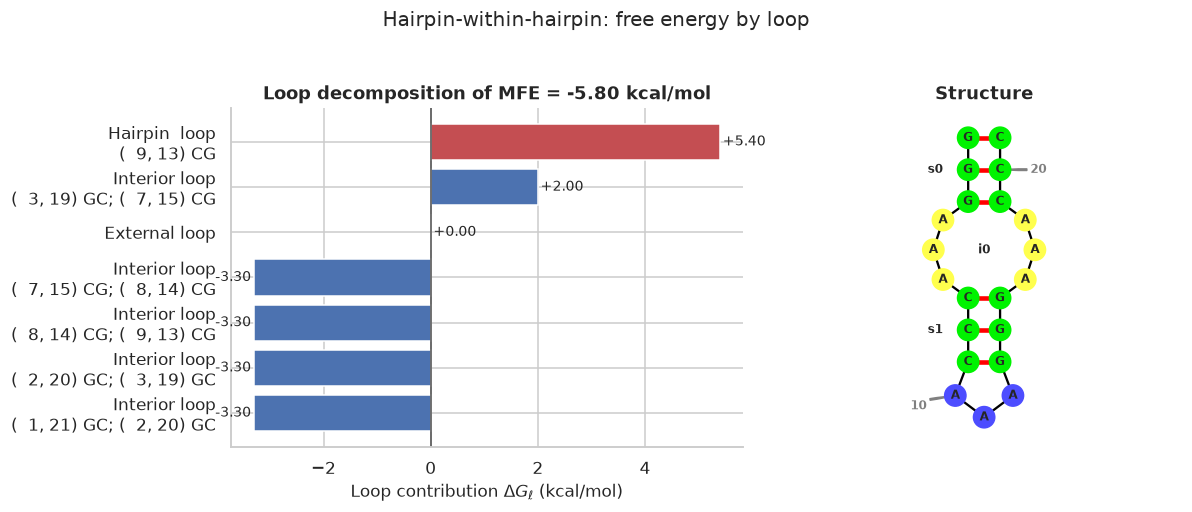

In [3]:
fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

# --- Left: per-loop energy contributions -------------------------------
ax0 = fig.add_subplot(gs[0])
decomp_1_sorted = decomp_1.sort_values("energy_kcal").reset_index(drop=True)
labels = [f"{row.loop_type}\n{row.detail}" if row.detail else row.loop_type
          for row in decomp_1_sorted.itertuples()]
colors = [LOOP_COLORS.get(t, PALETTE[4]) for t in decomp_1_sorted["loop_type"]]
bars = ax0.barh(labels, decomp_1_sorted["energy_kcal"], color=colors, edgecolor="white")
ax0.axvline(0, color="0.3", lw=1)
ax0.set_xlabel(r"Loop contribution $\Delta G_\ell$ (kcal/mol)")
ax0.set_title(f"Loop decomposition of MFE = {mfe_1:.2f} kcal/mol")
for bar, val in zip(bars, decomp_1_sorted["energy_kcal"]):
    ax0.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height() / 2,
             f"{val:+.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
sns.despine(ax=ax0)

# --- Right: forgi structure diagram -------------------------------------
ax1 = fig.add_subplot(gs[1])
bg_1 = fgb.BulgeGraph.from_dotbracket(structure_1, seq_1)
fvm.plot_rna(bg_1, ax=ax1, text_kwargs={"fontsize": 8}, lighten=0.3)
ax1.set_title("Structure")
ax1.set_axis_off()

fig.suptitle("Hairpin-within-hairpin: free energy by loop", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the two stacked base pairs at the very base
(`Interior loop (1,21)/(2,20)` and `(2,20)/(3,19)`, each $-3.30$ kcal/mol) and
the inner stem (`(7,15)/(8,14)` and `(8,14)/(9,13)`) are the stabilizing
helices — they dominate the negative side. The single `Hairpin loop` term
($+5.40$ kcal/mol) is the entropic cost of closing the inner loop, and the
`Interior loop (3,19);(7,15)` term ($+2.00$ kcal/mol) is the bulge between the
two stems. Their sum reproduces the MFE exactly: helices pay for loops.


## 4. Worked example 2 — how model details change $\Delta G$

The decomposition above was computed under ViennaRNA's *default* model
details: $T = 37^{\circ}\mathrm{C}$, `dangles = 2`, lonely pairs allowed. Each
of these is a modeling *choice*, not a property of the RNA itself, and each
changes every $\Delta G_\ell$ — and therefore the MFE.

### 4.1 Dangle treatment and lonely pairs

The `dangles` option controls how unpaired bases immediately adjacent to a
helix ("dangling ends") are scored:

| `dangles` | Meaning |
| :--- | :--- |
| `0` | Dangling-end energies ignored |
| `1` | Unpaired bases contribute to one adjacent helix only (old default) |
| `2` | Unpaired bases contribute to *both* adjacent helices (current default) |
| `3` | Co-axial stacking of helices across multiloops (mutually exclusive with dangles=2 in practice) |

`noLP = 1` forbids "lonely" base pairs — isolated pairs not part of a stack of
two or more — which are thermodynamically weak and rarely observed
structurally, so excluding them often gives more realistic predictions for
longer sequences.

We sweep these settings for one sequence below.


In [4]:
seq_2 = "GGGCUAUUAGCUCAGUUGGUAGAGCAGUUGACUUUUAAUCAAUUGGUCGCAGGUUCGAAUCCUGCAGAGAUCCA"  # tRNA-like, longer

settings = [
    ("dangles=0", {"dangles": 0, "noLP": 0}),
    ("dangles=1", {"dangles": 1, "noLP": 0}),
    ("dangles=2 (default)", {"dangles": 2, "noLP": 0}),
    ("dangles=2, noLP=1", {"dangles": 2, "noLP": 1}),
]

rows = []
for label, opts in settings:
    md_ = RNA.md()
    for key, val in opts.items():
        setattr(md_, key, val)
    fc = RNA.fold_compound(seq_2, md_)
    structure, mfe = fc.mfe()
    rows.append({"setting": label, "mfe": mfe, "structure": structure})

dangles_df = pd.DataFrame(rows)
dangles_df


,setting,mfe,structure
0,dangles=0,-17.100000,(((((...)))))........((.(((((((.......)))))))....
1,dangles=1,-20.700001,(((((...)))))........((.(((((((.......)))))))....
2,dangles=2 (default),-21.700001,(((((...)))))........((.(((((((.......)))))))....
3,"dangles=2, noLP=1",-21.700001,(((((...)))))........((.(((((((.......)))))))....


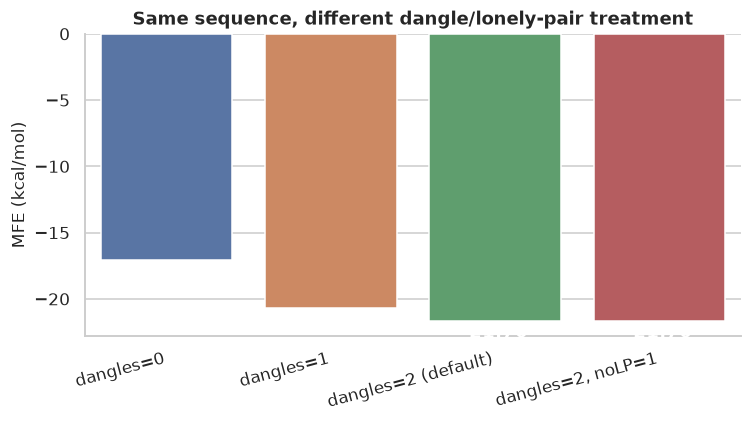

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=dangles_df, x="setting", y="mfe", hue="setting",
            palette=PALETTE[:len(dangles_df)], legend=False, ax=ax)
ax.set_ylabel("MFE (kcal/mol)")
ax.set_xlabel("")
ax.set_title("Same sequence, different dangle/lonely-pair treatment")
for i, v in enumerate(dangles_df["mfe"]):
    ax.text(i, v - 0.15, f"{v:.2f}", ha="center", va="top", color="white", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: `dangles=2` (the default) is the most favorable
because it lets unpaired bases stack against helices on *both* sides; `dangles=0`
ignores that stabilization entirely and gives the least negative MFE. Adding
`noLP=1` on top of `dangles=2` removes any isolated base pairs from
consideration, which can only raise (or leave unchanged) the MFE — exactly what
we see here. **The lesson**: always report which model details were used
alongside an MFE value; "$-25.4$ kcal/mol" is meaningless without them.


### 4.2 Temperature dependence

Now fix `dangles=2, noLP=0` (the default) and sweep temperature. Because every
$\Delta G_\ell = \Delta H_\ell - T \Delta S_\ell$, raising $T$ generally makes
loops *less* favorable relative to the unfolded state — the MFE should
increase (become less negative) as $T$ rises.


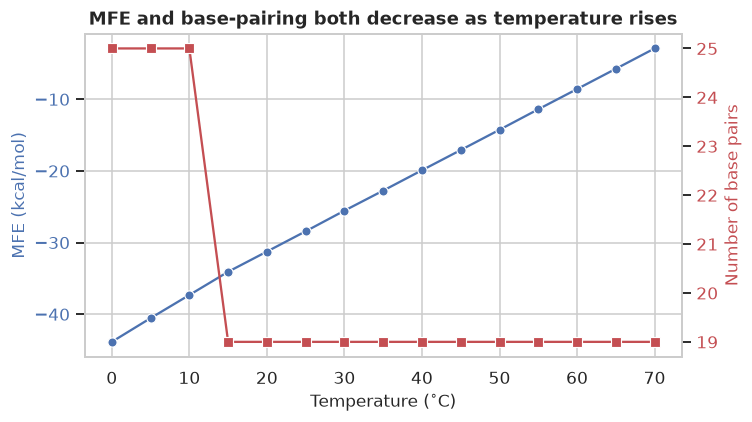

In [6]:
temperatures = np.arange(0, 75, 5)
temp_rows = []
for temp in temperatures:
    md_ = RNA.md()
    md_.temperature = float(temp)
    fc = RNA.fold_compound(seq_2, md_)
    structure, mfe = fc.mfe()
    temp_rows.append({"temperature": temp, "mfe": mfe, "n_pairs": structure.count("(")})

temp_df = pd.DataFrame(temp_rows)

fig, ax1 = plt.subplots(figsize=(7, 4))
sns.lineplot(data=temp_df, x="temperature", y="mfe", marker="o", color=PALETTE[0], ax=ax1)
ax1.set_xlabel(r"Temperature ($^{\circ}$C)")
ax1.set_ylabel("MFE (kcal/mol)", color=PALETTE[0])
ax1.tick_params(axis="y", labelcolor=PALETTE[0])

ax2 = ax1.twinx()
sns.lineplot(data=temp_df, x="temperature", y="n_pairs", marker="s", color=PALETTE[3], ax=ax2)
ax2.set_ylabel("Number of base pairs", color=PALETTE[3])
ax2.tick_params(axis="y", labelcolor=PALETTE[3])
ax2.grid(False)

ax1.set_title("MFE and base-pairing both decrease as temperature rises")
fig.tight_layout()
plt.show()


**Reading the figure**: as temperature increases from $0^{\circ}\mathrm{C}$
to $70^{\circ}\mathrm{C}$, the MFE rises toward zero (structure becomes less
favorable relative to the unfolded chain) and the number of base pairs in the
MFE structure drops — the molecule is progressively "melting". This is the
same physical process probed experimentally by UV-melting curves, here
predicted purely from the nearest-neighbor parameters.


## 5. Worked example 3 — GC content vs. free energy across random sequences

The nearest-neighbor parameters make G–C pairs (3 hydrogen bonds, better
stacking) systematically more stabilizing than A–U pairs. We can see this
empirically by folding many random sequences of the same length but different
GC fractions and plotting MFE per nucleotide against GC content.


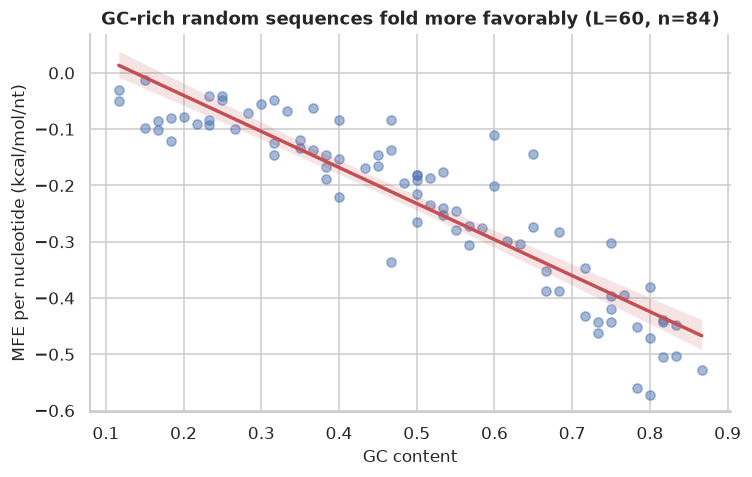

In [7]:
rng = random.Random(42)
LENGTH = 60
N_PER_GC = 12
gc_fractions = np.round(np.arange(0.2, 0.85, 0.1), 2)

gc_rows = []
for gc in gc_fractions:
    for _ in range(N_PER_GC):
        seq = "".join(
            rng.choice("GC") if rng.random() < gc else rng.choice("AU")
            for _ in range(LENGTH)
        )
        structure, mfe = RNA.fold(seq)
        gc_rows.append({
            "gc_target": gc,
            "gc_actual": (seq.count("G") + seq.count("C")) / LENGTH,
            "mfe_per_nt": mfe / LENGTH,
        })

gc_df = pd.DataFrame(gc_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.regplot(data=gc_df, x="gc_actual", y="mfe_per_nt", ax=ax,
            scatter_kws={"alpha": 0.5, "color": PALETTE[0]}, line_kws={"color": PALETTE[3]})
ax.set_xlabel("GC content")
ax.set_ylabel("MFE per nucleotide (kcal/mol/nt)")
ax.set_title(f"GC-rich random sequences fold more favorably (L={LENGTH}, n={len(gc_df)})")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: each point is one random 60-nt sequence; the
downward trend confirms that higher GC content yields a more negative
(more favorable) MFE per nucleotide on average — directly traceable to the
larger $-\Delta G_\ell$ stacking terms for G–C-containing helices in Section 3.
There is still substantial scatter at fixed GC content, because the *order* of
bases (not just their composition) determines which structure — and hence
which loop terms — actually forms.


## 6. Case study — full free-energy profile of a small functional RNA

Putting it together: take a slightly longer, biologically inspired sequence
(a cloverleaf-like tRNA fragment), fold it, decompose its MFE by loop type,
and look at its forgi diagram with each helix's contribution annotated.


In [8]:
seq_3 = seq_2  # reuse the tRNA-like sequence from Section 4
fc_3 = RNA.fold_compound(seq_3)
structure_3, mfe_3 = fc_3.mfe()
total_3, decomp_3 = eval_structure_verbose_df(fc_3, structure_3)

# Aggregate by loop type for a compact summary.
summary_3 = decomp_3.groupby("loop_type", as_index=False)["energy_kcal"].sum()
summary_3 = summary_3.sort_values("energy_kcal")

print(f"Sequence ({len(seq_3)} nt): {seq_3}")
print(f"Structure:               {structure_3}")
print(f"MFE: {mfe_3:.2f} kcal/mol across {len(decomp_3)} loops")
summary_3


Sequence (74 nt): GGGCUAUUAGCUCAGUUGGUAGAGCAGUUGACUUUUAAUCAAUUGGUCGCAGGUUCGAAUCCUGCAGAGAUCCA
Structure:               (((((...)))))........((.(((((((.......))))))).))(((((.......))))).........
MFE: -21.70 kcal/mol across 20 loops


,loop_type,energy_kcal
2,Interior loop,-33.3
0,External loop,-4.6
1,Hairpin loop,16.2


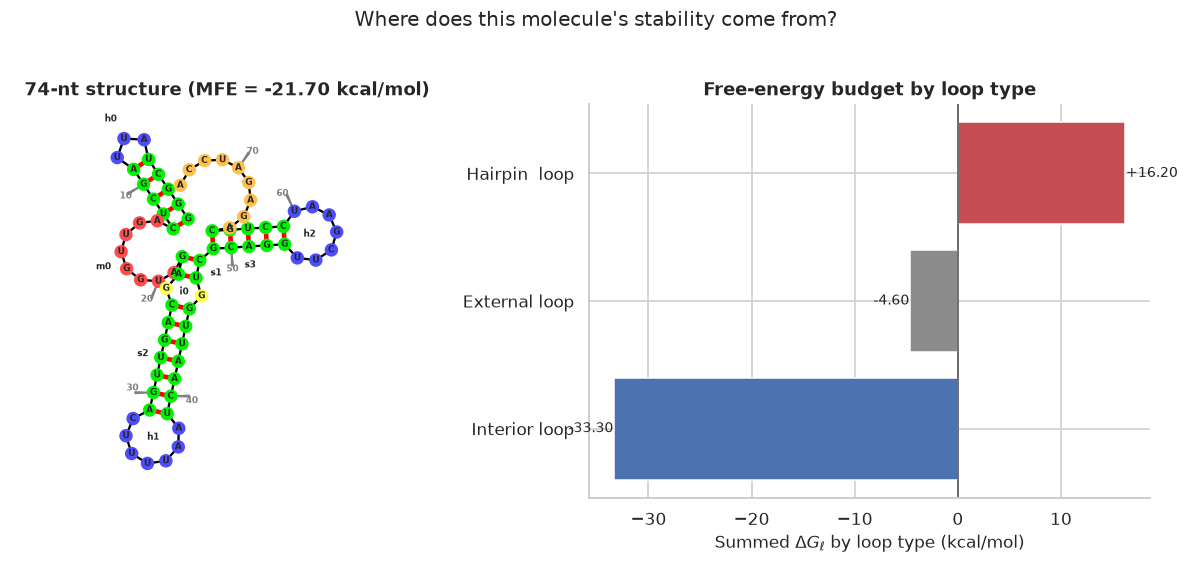

In [9]:
fig = plt.figure(figsize=(11, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3])

ax0 = fig.add_subplot(gs[0])
bg_3 = fgb.BulgeGraph.from_dotbracket(structure_3, seq_3)
fvm.plot_rna(bg_3, ax=ax0, text_kwargs={"fontsize": 6}, lighten=0.3)
ax0.set_title(f"{len(seq_3)}-nt structure (MFE = {mfe_3:.2f} kcal/mol)")
ax0.set_axis_off()

ax1 = fig.add_subplot(gs[1])
colors = [LOOP_COLORS.get(t, PALETTE[4]) for t in summary_3["loop_type"]]
bars = ax1.barh(summary_3["loop_type"], summary_3["energy_kcal"], color=colors, edgecolor="white")
ax1.axvline(0, color="0.3", lw=1)
ax1.set_xlabel(r"Summed $\Delta G_\ell$ by loop type (kcal/mol)")
ax1.set_title("Free-energy budget by loop type")
for bar, val in zip(bars, summary_3["energy_kcal"]):
    ax1.text(val + (0.1 if val >= 0 else -0.1), bar.get_y() + bar.get_height() / 2,
             f"{val:+.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
sns.despine(ax=ax1)

fig.suptitle("Where does this molecule's stability come from?", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the stacked helices (green segments in the forgi
diagram, "Interior loop" bars on the right) provide essentially all of the
favorable free energy, while the hairpin loops and multiloop junction (blue
and red regions) are the entropic "price" paid to form them. This budget view
generalizes the two-term picture from Section 3 to a structure with multiple
helices and a multiloop junction.


## 7. Best practices and common pitfalls

- **Always state model details with an energy value.** An MFE of $-12.3$
  kcal/mol means different things at `dangles=1` vs `dangles=2`, or at
  $25^{\circ}\mathrm{C}$ vs $37^{\circ}\mathrm{C}$. When comparing energies
  across sequences or conditions, build every `fold_compound` from the *same*
  `RNA.md()` settings.
- **Reuse one `RNA.md()` object per condition, not per sequence**, then pass
  it to `RNA.fold_compound(seq, md)` for each sequence — this guarantees an
  apples-to-apples comparison and avoids silently falling back to defaults.
- **`eval_structure` accepts *any* dot-bracket structure** for the sequence,
  not just the MFE — including biologically known or experimentally derived
  structures. This is the right tool for "is the textbook structure close to
  optimal?" questions; just make sure the structure string is the same length
  as the sequence and balanced.
- **Units**: `eval_structure*` and `mfe()` return kcal/mol as Python floats,
  but the *verbose* text stream (and `subopt`'s energy-window argument, used in
  notebook 4) is in units of $10\,\text{cal/mol}$ — divide by 100, not 10, to
  get kcal/mol (the helper in Section 3 does this for you).
- **`noLP=1` changes which structure is optimal**, not just its energy — don't
  apply it after the fact to an MFE structure computed without it; rebuild the
  fold compound with the option set *before* calling `mfe()`.
- **Pitfall**: `eval_structure_verbose` writes to the process's real
  stdout (file descriptor 1), so `contextlib.redirect_stdout` alone does
  **not** capture it — you need the `os.dup2`-based redirection used in
  Section 3's helper.


## 8. Summary

- The MFE is a **sum of per-loop free-energy terms** drawn from the
  nearest-neighbor (Turner) parameter set; `eval_structure_verbose` exposes
  this sum term-by-term, and we turned it into a reusable `DataFrame` and bar
  chart.
- Helical stacks (interior loops with 0 unpaired bases) are the main source of
  stabilizing ($\Delta G_\ell < 0$) free energy; hairpin, interior, and
  multiloop terms are the entropic costs of forming junctions and loops.
- **Model details matter**: `dangles`, `noLP`, and especially `temperature`
  shift every term and therefore the MFE — always fix and report them.
- `eval_structure` lets you score *any* structure for a sequence, enabling
  "what-if" comparisons without re-running the full folding algorithm.
- GC-rich sequences fold more favorably on average, a direct, visualizable
  consequence of the per-loop parameter values.

**Next**: [03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
moves from a single MFE structure to the full Boltzmann ensemble — computing
the partition function, base-pair probabilities, and what they reveal about
structural uncertainty that a single MFE structure hides.


## 9. Exercises

1. Pick any sequence from notebook 1 and run it through
   `eval_structure_verbose_df`. Which loop contributes the most to stability?
   Which contributes the most "cost"?
2. Repeat the temperature sweep (Section 4.2) for a short hairpin (≈20 nt) vs.
   the 75-nt sequence used here. Does the shorter sequence "melt" at a lower
   or higher temperature? Why might molecule length affect this?
3. Using `eval_structure`, compute the free energy of the **fully unfolded**
   structure (a string of `.` the same length as your sequence) for a sequence
   of your choice. Confirm it equals 0, and explain why this is the natural
   reference state for $\Delta G$.
